In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
archivo = "Analisis GAC Full7agosto 2026(Leads Reales).csv"
df = pd.read_csv(archivo, skiprows=2, nrows=29, thousands=",", encoding="utf-8-sig")
df

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1%,72%,NaN,NaN
2,NaN,Marzo,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5%,72%,NaN,NaN
3,NaN,Abril,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8%,69%,NaN,NaN
4,NaN,Mayo,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7%,65%,NaN,NaN
5,NaN,Junio,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,1.0%,64%,NaN,NaN
6,NaN,Julio,954.0,112.0,251.0,12.0,9.0,570.0,5.0,21.0,3.7%,60%,NaN,NaN
7,NaN,Agosto,1409.0,504.0,324.0,17.0,18.0,546.0,22.0,17.0,3.1%,39%,NaN,NaN
8,NaN,Septiembre,1315.0,431.0,314.0,14.0,26.0,530.0,42.0,17.0,3.2%,40%,NaN,NaN
9,NaN,Octubre,1973.0,514.0,606.0,18.0,13.0,822.0,72.0,23.0,2.8%,42%,NaN,NaN


In [17]:
df = df.drop(columns=["Unnamed: 12", "Unnamed: 13"])
df.columns = df.columns.str.strip()
df.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion',
       'Efectividad de Leads'],
      dtype='str')

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Año                   3 non-null      float64
 1   Mes                   29 non-null     str    
 2   Total                 28 non-null     float64
 3   Ilocalizable          28 non-null     float64
 4   No Contesta           28 non-null     float64
 5   D. Incorrectos        28 non-null     float64
 6   Duplicados            28 non-null     float64
 7   Efectivos             28 non-null     float64
 8   Abiertos              28 non-null     float64
 9   Ventas                28 non-null     float64
 10  Conversion            28 non-null     str    
 11  Efectividad de Leads  28 non-null     str    
dtypes: float64(9), str(3)
memory usage: 2.8 KB


In [19]:
df.isnull().sum()

Año                     26
Mes                      0
Total                    1
Ilocalizable             1
No Contesta              1
D. Incorrectos           1
Duplicados               1
Efectivos                1
Abiertos                 1
Ventas                   1
Conversion               1
Efectividad de Leads     1
dtype: int64

In [20]:
df["Año"] = df["Año"].ffill()
df["Mes"] = df["Mes"].str.strip()
df.head(15)

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024.0,Febrero,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1%,72%
2,2024.0,Marzo,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5%,72%
3,2024.0,Abril,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8%,69%
4,2024.0,Mayo,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7%,65%
5,2024.0,Junio,967.0,140.0,173.0,31.0,3.0,620.0,17.0,6.0,1.0%,64%
6,2024.0,Julio,954.0,112.0,251.0,12.0,9.0,570.0,5.0,21.0,3.7%,60%
7,2024.0,Agosto,1409.0,504.0,324.0,17.0,18.0,546.0,22.0,17.0,3.1%,39%
8,2024.0,Septiembre,1315.0,431.0,314.0,14.0,26.0,530.0,42.0,17.0,3.2%,40%
9,2024.0,Octubre,1973.0,514.0,606.0,18.0,13.0,822.0,72.0,23.0,2.8%,42%


In [21]:
for columna in ["Conversion", "Efectividad de Leads"]:
    df[columna] = df[columna].str.replace("%", "", regex=False).astype(float)
df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024.0,Febrero,543.0,108.0,33.0,0.0,1.0,389.0,1.0,12.0,3.1,72.0
2,2024.0,Marzo,178.0,37.0,13.0,0.0,0.0,128.0,1.0,7.0,5.5,72.0
3,2024.0,Abril,416.0,79.0,46.0,3.0,0.0,288.0,1.0,8.0,2.8,69.0
4,2024.0,Mayo,422.0,33.0,100.0,17.0,0.0,274.0,5.0,13.0,4.7,65.0


In [22]:
df[df.isnull().any(axis=1)]

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
print("Filas antes de quitar nulos:", df.shape[0])
 
df = df.dropna()
df = df.reset_index(drop=True)
 
columnas_conteo = [
    "Total", "Ilocalizable", "No Contesta", "D. Incorrectos",
    "Duplicados", "Efectivos", "Abiertos", "Ventas",
]
for columna in columnas_conteo:
    df[columna] = df[columna].astype(int)
 
print("Filas después de quitar nulos:", df.shape[0])

Filas antes de quitar nulos: 29
Filas después de quitar nulos: 28


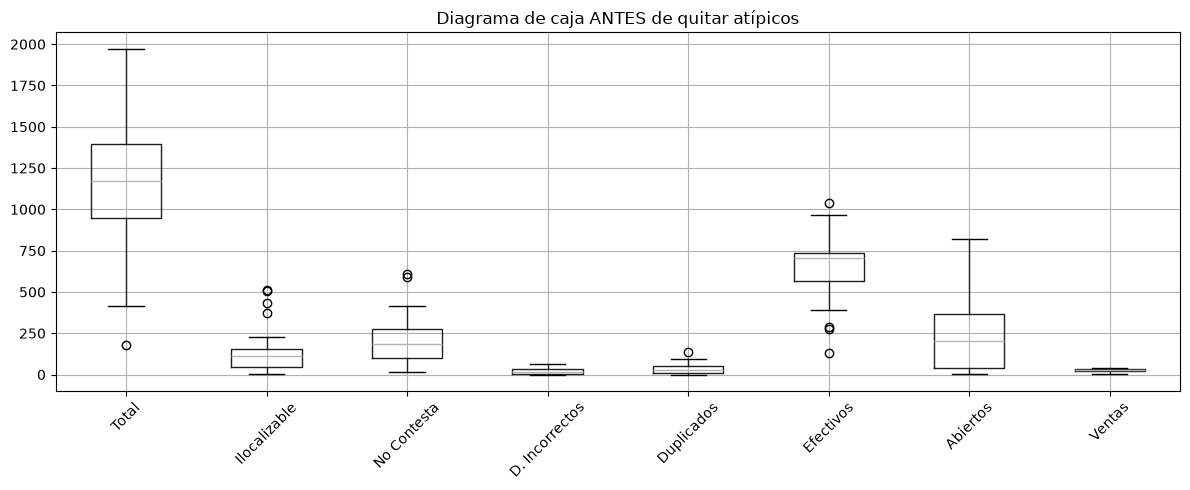

In [24]:
df[columnas_conteo].boxplot(figsize=(12, 5), rot=45)
plt.title("Diagrama de caja ANTES de quitar atípicos")
plt.tight_layout()
plt.savefig("boxplot_antes_outliers.png", dpi=150)
plt.show()

In [25]:
fila_valida = pd.Series(True, index=df.index)
 
for columna in columnas_conteo:
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
 
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
 
    es_atipico = (df[columna] < limite_inf) | (df[columna] > limite_sup)
    print(f"{columna}: límites [{limite_inf:.0f}, {limite_sup:.0f}] -> atípicos: {es_atipico.sum()}")
 
    fila_valida = fila_valida & (~es_atipico)

Total: límites [271, 2072] -> atípicos: 1
Ilocalizable: límites [-121, 319] -> atípicos: 4
No Contesta: límites [-160, 540] -> atípicos: 2
D. Incorrectos: límites [-40, 75] -> atípicos: 0
Duplicados: límites [-50, 114] -> atípicos: 1
Efectivos: límites [303, 999] -> atípicos: 4
Abiertos: límites [-460, 864] -> atípicos: 0
Ventas: límites [-6, 62] -> atípicos: 0


In [26]:
df[~fila_valida][["Año", "Mes"] + columnas_conteo]

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas
1,2024.0,Marzo,178,37,13,0,0,128,1,7
2,2024.0,Abril,416,79,46,3,0,288,1,8
3,2024.0,Mayo,422,33,100,17,0,274,5,13
6,2024.0,Agosto,1409,504,324,17,18,546,22,17
7,2024.0,Septiembre,1315,431,314,14,26,530,42,17
8,2024.0,Octubre,1973,514,606,18,13,822,72,23
9,2024.0,Noviembre,1562,153,321,44,4,1040,79,22
10,2024.0,Diciembre,1282,374,193,60,53,965,330,32
11,2025.0,Enero,1042,17,104,62,136,723,222,26
18,2025.0,Agosto,1419,81,591,7,59,681,338,27


In [27]:
print("Filas antes de quitar atípicos:", df.shape[0])
 
df = df[fila_valida]
df = df.reset_index(drop=True)
 
print("Filas después de quitar atípicos:", df.shape[0])

Filas antes de quitar atípicos: 28
Filas después de quitar atípicos: 18


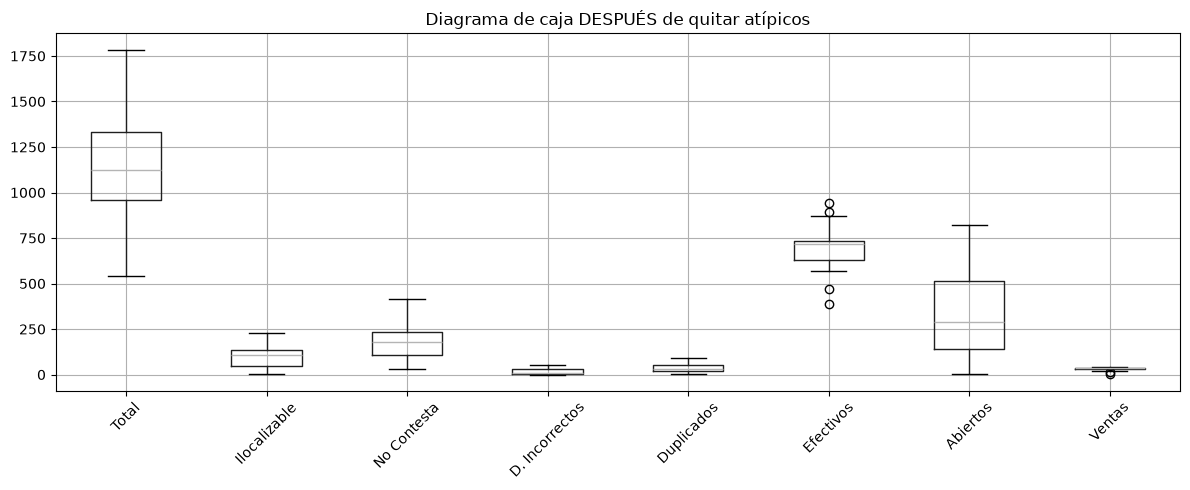

In [28]:
df[columnas_conteo].boxplot(figsize=(12, 5), rot=45)
plt.title("Diagrama de caja DESPUÉS de quitar atípicos")
plt.tight_layout()
plt.savefig("boxplot_despues_outliers.png", dpi=150)
plt.show()

In [29]:
df.describe()

,Año,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.00000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,2025.111111,1134.555556,99.222222,180.666667,16.277778,35.50000,693.722222,327.277778,31.277778,4.494444,63.333333
std,0.676400,322.388371,64.879577,107.158486,17.186881,26.02318,137.999917,247.568601,10.185373,1.260472,10.261292
min,2024.000000,543.000000,5.000000,33.000000,0.000000,1.00000,389.000000,1.000000,6.000000,1.000000,47.000000
25%,2025.000000,957.250000,47.250000,108.500000,3.000000,17.25000,630.000000,143.250000,30.000000,4.000000,58.250000
50%,2025.000000,1124.500000,110.000000,178.500000,8.500000,31.00000,719.000000,289.000000,34.500000,4.500000,62.000000
75%,2025.750000,1331.250000,137.000000,235.250000,29.500000,52.75000,734.750000,514.250000,38.000000,5.650000,70.000000
max,2026.000000,1785.000000,228.000000,413.000000,52.000000,93.00000,944.000000,823.000000,41.000000,5.900000,83.000000


In [30]:
df["Año"] = pd.to_numeric(df["Año"]).astype(int)
df["Año"].head()

0    2024
1    2024
2    2024
3    2025
4    2025
Name: Año, dtype: int64

In [31]:
meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12,
}
 
df["Mes"] = df["Mes"].map(meses)
df["Mes"] = pd.to_numeric(df["Mes"])
df.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads
0,2024,2,543,108,33,0,1,389,1,12,3.1,72.0
1,2024,6,967,140,173,31,3,620,17,6,1.0,64.0
2,2024,7,954,112,251,12,9,570,5,21,3.7,60.0
3,2025,2,561,9,39,14,31,468,150,20,4.3,83.0
4,2025,3,925,39,98,3,54,731,125,30,4.1,79.0


In [32]:
columnas_leads = [
    "Total", "Ilocalizable", "No Contesta", "D. Incorrectos",
    "Duplicados", "Efectivos", "Abiertos", "Ventas",
]

In [33]:
correlaciones = df[columnas_leads].corr()
correlaciones

,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas
Total,1.000000,0.682058,0.339954,0.654584,0.354193,0.820418,0.819765,0.608402
Ilocalizable,0.682058,1.000000,-0.058750,0.745128,-0.086091,0.390606,0.517175,0.056782
No Contesta,0.339954,-0.058750,1.000000,-0.097234,0.049044,0.282912,0.086850,0.435561
D. Incorrectos,0.654584,0.745128,-0.097234,1.000000,-0.073191,0.284704,0.598829,0.073796
Duplicados,0.354193,-0.086091,0.049044,-0.073191,1.000000,0.666081,0.244164,0.436867
Efectivos,0.820418,0.390606,0.282912,0.284704,0.666081,1.000000,0.548536,0.605586
Abiertos,0.819765,0.517175,0.086850,0.598829,0.244164,0.548536,1.000000,0.646575
Ventas,0.608402,0.056782,0.435561,0.073796,0.436867,0.605586,0.646575,1.000000


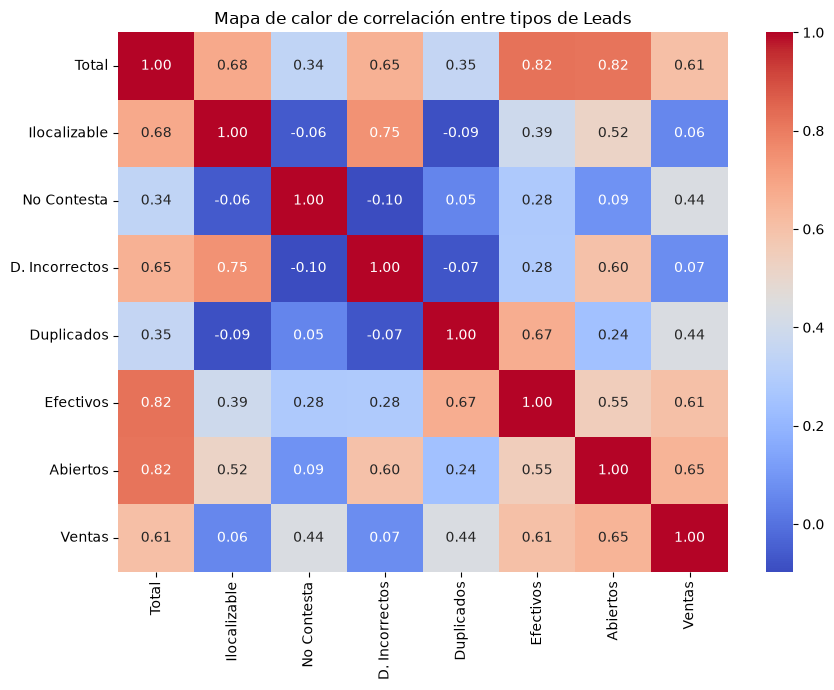

In [34]:
plt.figure(figsize=(9, 7))
sns.heatmap(correlaciones, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de calor de correlación entre tipos de Leads")
plt.tight_layout()
plt.savefig("heatmap_correlacion_leads.png", dpi=150)
plt.show()

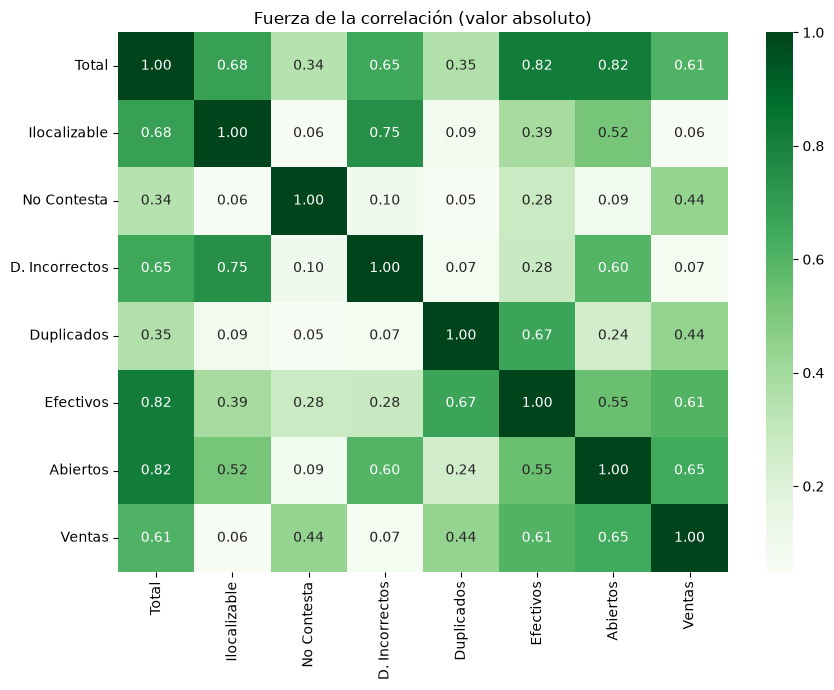

In [35]:
correlaciones_abs = correlaciones.abs()
 
plt.figure(figsize=(9, 7))
sns.heatmap(correlaciones_abs, annot=True, fmt=".2f", cmap="Greens")
plt.title("Fuerza de la correlación (valor absoluto)")
plt.tight_layout()
plt.savefig("heatmap_correlacion_leads_abs.png", dpi=150)
plt.show()

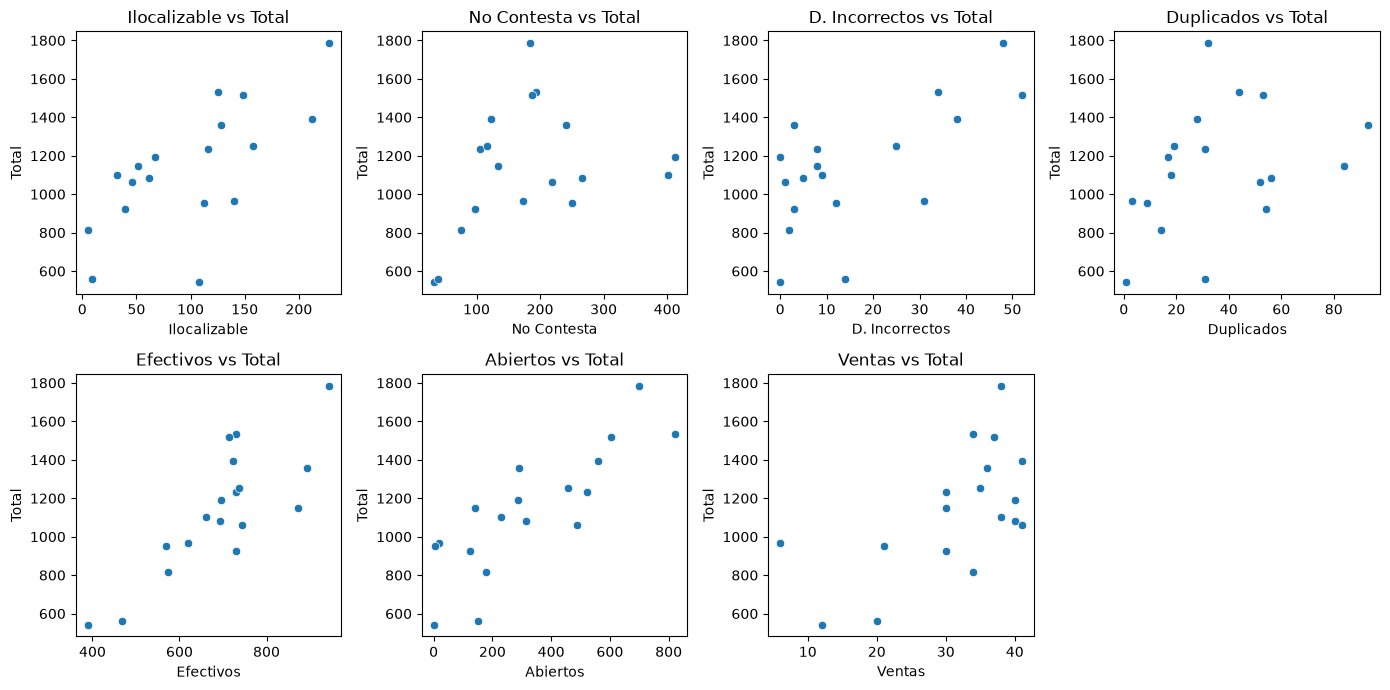

In [36]:
otros_tipos = [
    "Ilocalizable", "No Contesta", "D. Incorrectos",
    "Duplicados", "Efectivos", "Abiertos", "Ventas",
]
 
plt.figure(figsize=(14, 7))
for i, columna in enumerate(otros_tipos):
    plt.subplot(2, 4, i + 1)  # cuadrícula de 2 filas x 4 columnas
    sns.scatterplot(x=columna, y="Total", data=df)
    plt.title(f"{columna} vs Total")
 
plt.tight_layout()
plt.savefig("scatter_grid_leads_vs_total.png", dpi=150)
plt.show()

In [37]:
correlaciones["Total"].sort_values(ascending=False)

Total             1.000000
Efectivos         0.820418
Abiertos          0.819765
Ilocalizable      0.682058
D. Incorrectos    0.654584
Ventas            0.608402
Duplicados        0.354193
No Contesta       0.339954
Name: Total, dtype: float64

In [38]:
print(df.dtypes)
 
df.to_csv("Leads_Reales_Depurado.csv", index=False, encoding="utf-8-sig")
print("\nArchivo guardado: Leads_Reales_Depurado.csv")

Año                       int64
Mes                       int64
Total                     int64
Ilocalizable              int64
No Contesta               int64
D. Incorrectos            int64
Duplicados                int64
Efectivos                 int64
Abiertos                  int64
Ventas                    int64
Conversion              float64
Efectividad de Leads    float64
dtype: object

Archivo guardado: Leads_Reales_Depurado.csv
